In [2]:
import sys
import json
from shapely.geometry import LineString

# poly = [
# 	[-73.76343785810529, 45.42492256321245],
# 	[-73.69924976027211, 45.55480344886365],
# 	[-73.50960310758373, 45.53181488567199],
# 	[-73.46729731583024, 45.44232555570369],
# 	[-73.50303841575999, 45.41673106272731],
# 	[-73.76343785810529, 45.42492256321245],
# ]
# highway = [
# 	'motorway',
# 	'motorway_link',
# 	'trunk',
# 	'trunk_link',
# 	'primary',
# 	'primary_link',
# 	'secondary',
# 	'secondary_link',
# 	'tertiary',
# 	'tertiary_link',
# 	'residential',
# ]

poly = [
	[-73.68843594532505, 45.44440233371736],
	[-73.68839910204119, 45.552179931161376],
	[-73.4522748979573, 45.552179931161376],
	[-73.45223805467343, 45.44440233371736],
	[-73.68843594532505, 45.44440233371736],
]
highway = ['motorway', 'motorway_link', 'trunk', 'trunk_link', 'primary', 'primary_link']

params = {'poly': poly, 'highway': highway, 'elevation': True, 'extended_cycleway': False}


default = {'scenario': 'test', 'training_folder': '../..', 'params': params}  # Default execution parameters
manual, argv = (True, default) if 'ipykernel' in sys.argv[0] else (False, dict(default, **json.loads(sys.argv[1])))

In [3]:
from osm_importer import overpass, road


In [4]:
params = argv['params']
add_elevation = params['elevation']
extended_cycleway = params['extended_cycleway']
split_direction = False


In [5]:
# get bbox or a polygon
poly = params['poly']
bbox = overpass.get_bbox(poly)
# get requested highway
highway_list = params['highway']

In [6]:
cycleway_list = None
if 'cycleway' in highway_list:
	cycleway_list = [
		'lane',
		'opposite',
		'opposite_lane',
		'track',
		'opposite_track',
		'share_busway',
		'opposite_share_busway',
		'shared_lane',
	]
	if extended_cycleway:
		cycleway_list = ['*']

In [7]:
CYCLEWAY_COLUMNS = ['cycleway:both', 'cycleway:left', 'cycleway:right']
HIGHWAY_COLUMNS = ['highway', 'maxspeed', 'lanes', 'name', 'oneway', 'surface']

columns = HIGHWAY_COLUMNS.copy()
# if cycleway is requested. add cyclway tags to the request.
# https://wiki.openstreetmap.org/wiki/Map_features#When_cycleway_is_drawn_as_its_own_way_(see_Bicycle)
if cycleway_list:
	if extended_cycleway:
		columns += ['cycleway']
	else:
		columns += CYCLEWAY_COLUMNS
		columns += ['cycleway']

# Start

# Overpass API request
query = overpass.get_overpass_query(bbox, key='highway', tag_list=highway_list)
if cycleway_list:
	cycleway_query = overpass.get_overpass_query(bbox, key='cycleway', tag_list=cycleway_list)
	query = query + cycleway_query
data = overpass.get_overpass_data(query)

Overpass API error 504: <?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" xml:
retrying in 2 seconds


In [8]:
df = overpass.ways_to_geojson(data, LineString)
df = overpass.add_tags_as_columns(df, tags=columns)

<Axes: >

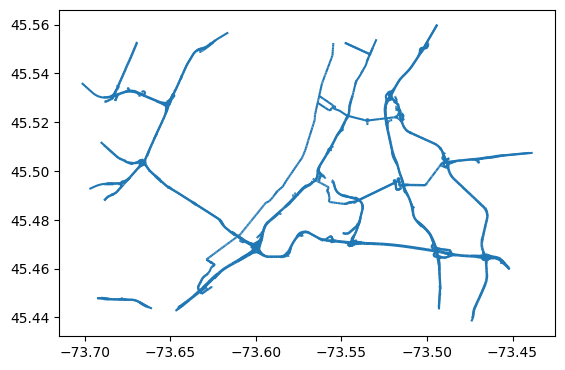

In [9]:
df.plot()

In [10]:
# Create links and nodes netowrks from ways of OSM
print('Convert ways to links and node ...')
links, nodes = road.get_links_and_nodes(df)
links = links.drop(columns='osmid')

links.index = [f'rlink_{i}' for i in links.index]
links['a'] = links['a'].apply(lambda x: f'rnode_{x}')
links['b'] = links['b'].apply(lambda x: f'rnode_{x}')
nodes.index = [f'rnode_{i}' for i in nodes.index]

Convert ways to links and node ...


In [11]:
import geopandas as gpd
from shapely.geometry import Polygon

print('restrict links to polygon')
poly_df = gpd.GeoDataFrame(geometry=[Polygon(poly)], crs=4326)
links = gpd.sjoin(links, poly_df, how='inner', predicate='intersects').drop(columns='index_right')

restrict links to polygon


In [12]:
import numpy as np
from osm_importer.road import (
	get_links_and_nodes,
	clean_oneway,
	clean_maxspeed,
	clean_lanes,
	rectify_geometry_direction,
	drop_duplicated_links,
	simplify,
	split_oneway,
	main_strongly_connected_component,
	process_list_in_col,
	remove_list_in_col,
	fill_na_col,
	get_epsg,
)
from osm_importer.bike import test_bicycle_process, extended_bicycle_process
from osm_importer.overpass import get_overpass_query, get_bbox, get_overpass_data, add_tags_as_columns, ways_to_geojson
from osm_importer.elevation import get_elevation_from_srtm, calc_incline

In [13]:
split_direction = False

In [14]:
# simplify Linestring geometry. (remove anchor nodes)
links.geometry = links.simplify(0.00005)

if 'cycleway' in links.columns:
	if extended_cycleway:
		links = extended_bicycle_process(links)
	else:
		links = test_bicycle_process(links, CYCLEWAY_COLUMNS, highway_list)

links = links.drop(columns='tags', errors='ignore')
# convert oneway to bool.
links = clean_oneway(links)

# remove string in maxspeed
links = clean_maxspeed(links)

# remove string in maxspeed
links = clean_lanes(links)

# make sure the geometry are in the right direction (a->b)
links = rectify_geometry_direction(links, nodes)

# remove duplicated links (a-b)
print('simplifying links ...')
links = drop_duplicated_links(links)

# simplify. remove deg 2 nodes when possible. group by oneway and highway to merge each links.
links = simplify(links)

# split onwway into 2 links a-b, b-a
if split_direction:
	links = split_oneway(links)

# Clean Cul de Sac
print('Remove Cul de Sac ...')
links, nodes = main_strongly_connected_component(links, nodes, not split_direction)

print('removing list in columns ...')
links['maxspeed'] = links['maxspeed'].apply(lambda x: process_list_in_col(x, float, np.nanmean))
links['lanes'] = links['lanes'].apply(lambda x: process_list_in_col(x, float, lambda x: np.floor(np.nanmean(x))))
if 'cycleway' in links.columns:
	# sort and take last. sorted = [no,shared,yes]. so yes or shared if there is a list
	links['cycleway'] = links['cycleway'].apply(lambda x: process_list_in_col(x, str, lambda x: np.sort(x)[-1]))
	links['cycleway_reverse'] = links['cycleway_reverse'].apply(
		lambda x: process_list_in_col(x, str, lambda x: np.sort(x)[-1])
	)

for col in ['highway', 'name', 'surface']:
	links[col] = links[col].apply(lambda x: remove_list_in_col(x, 'first'))

# Fill NaN with mean values by highway
links = fill_na_col(links, 'highway', 'maxspeed', lambda x: np.mean(x))
links = fill_na_col(links, 'highway', 'lanes', lambda x: np.floor(np.mean(x)))

# Add length
epsg = get_epsg(nodes.iloc[0]['geometry'].y, nodes.iloc[0]['geometry'].x)
links['length'] = links.to_crs(epsg).length

# Add Time
links['time'] = links['length'] / (links['maxspeed'] * 1000 / 3600)
links = links.rename(columns={'maxspeed': 'speed'})

# reindex and remove ununsed nodes
links = links.reset_index(drop=True)
links.index = 'rlink_' + links.index.astype(str)
nodes_set = set(links['a']).union(set(links['b']))
nodes = nodes.loc[list(nodes_set)].sort_index()

if add_elevation:
	print('Adding elevation')
	el_dict = get_elevation_from_srtm(nodes)
	nodes['elevation'] = nodes.index.map(el_dict.get)
	# incline from node a to b in deg. neg if going down (if b is lower dans a)
	links['incline'] = calc_incline(
		links['a'].apply(lambda x: el_dict.get(x)).values,
		links['b'].apply(lambda x: el_dict.get(x)).values,
		links['length'].values,
	)


0 geometry to inverse
simplifying links ...
0 links dropped
435 deg 2 nodes
find path with large cutoff for 2  origins
find path with large cutoff for 1  origins
find path with large cutoff for 1  origins
find path with large cutoff for 13  origins
find path with large cutoff for 1  origins
find path with large cutoff for 8  origins
0 links were not merge because the oneway field is not the same
0 links were not merge because the highway field is not the same
0 merged_links unmerged because the geometry became a multilinestring
Remove Cul de Sac ...
removing list in columns ...
Adding elevation
file save to /tmp


<Axes: >

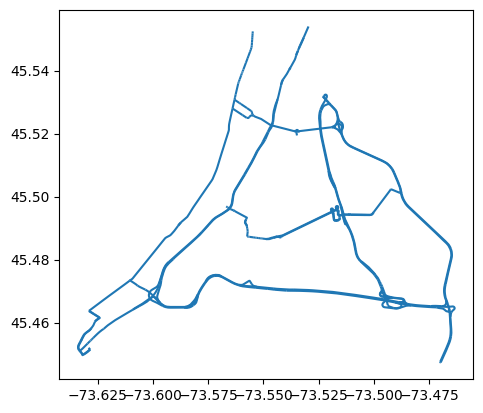

In [16]:
links.plot()